In [3]:
## load the 10 low activity seqs and their annotations
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/"
                   "Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src")
import numpy as np, pandas as pd, torch
from pathlib import Path
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

SIT = Path("/grid/koo/home/pmantill/projects/situate/data")
names = (SIT / "mcs_k562/names.txt").read_text().splitlines()
low = {i: int(n.split(":")[1]) for i, n in enumerate(names) if n.startswith("rep ")}  # situate row -> jointlib seq_idx

lib = pd.read_pickle("/grid/koo/home/pmantill/projects/Virtual_Experiments/MoConSwap_mpra/"
                     "SEAM_jointlib900/libraries/jointlib900_library.pkl")["df"]
lib = lib[lib.cell_type == "K562"].set_index("seq_idx")
wt_seqs = {i: lib.loc[s, "sequence"] for i, s in low.items()}   # 230bp WT insert strings

ann = pd.read_csv(SIT / "annotations/mcs_k562/edits.csv")
regions = {i: list(zip(g.start, g.end))                         # annotated motifs, var-region coords [0,200)
           for i, g in ann[ann.sequence_name.isin(low)].groupby("sequence_name")}


In [4]:
# KO each annotated region with the matching region from 20 dinuc-shuffled WT replicates, predict chimeric K562 activity
ADAPTER = 15      # annotation coords are insert[15:215]; offset into the 230bp insert
N_SHUF = 20

CKPT = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
model = EncoderMPRAModel.from_checkpoint(CKPT, device="cuda").eval()
cfg = torch.load(CKPT, map_location="cpu", weights_only=False)["construct_config"]
suffix = one_hot_encode(cfg["promoter_seq"] + cfg["barcode_seq"]).float()  # (4,51) promoter+barcode appended to every insert

@torch.no_grad()
def predict_k562(insert_ohe):                                  # (B,4,230) -> (B,) K562 pred
    x = torch.cat([insert_ohe, suffix.expand(len(insert_ohe), -1, -1)], 2)  # (B,4,281)
    return model(x.transpose(1, 2).cuda()).cpu().numpy()

wt_pred, ko_pred = {}, {}
for i, seq in wt_seqs.items():
    wt = one_hot_encode(seq).float()                          # (4,230)
    shuf = dinucleotide_shuffle(wt.unsqueeze(0), n=N_SHUF, random_state=0)[0]  # (20,4,230)
    chim = wt.unsqueeze(0).repeat(N_SHUF, 1, 1).clone()       # (20,4,230)
    for s, e in regions[i]:                                   # knock out every annotated motif at once
        chim[:, :, s + ADAPTER:e + ADAPTER] = shuf[:, :, s + ADAPTER:e + ADAPTER]
    wt_pred[i] = predict_k562(wt.unsqueeze(0))[0]
    ko_pred[i] = predict_k562(chim)                           # (20,) one per shuffle replicate


KeyError: 12

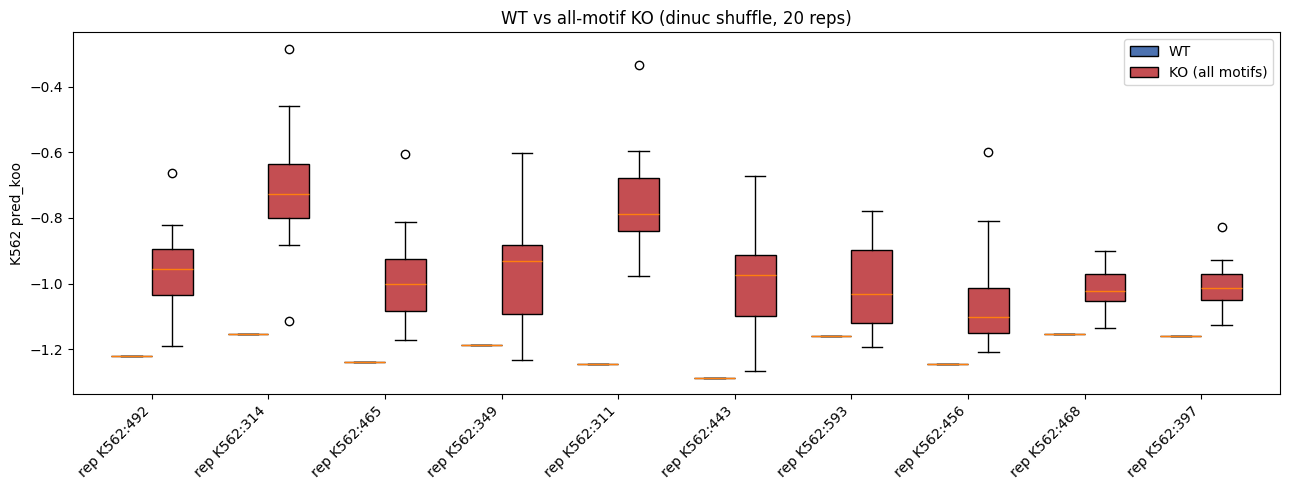

In [ ]:
# WT vs KO per seq: two boxes side by side (WT is one value -> flat line, KO = 20 shuffle reps)
import matplotlib.pyplot as plt
idxs = list(wt_seqs)
x = np.arange(len(idxs))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b_wt = ax.boxplot([[wt_pred[i]] for i in idxs], positions=x - w/2, widths=w, patch_artist=True)
b_ko = ax.boxplot([ko_pred[i] for i in idxs], positions=x + w/2, widths=w, patch_artist=True)
for b in b_wt["boxes"]: b.set_facecolor("#4c72b0")
for b in b_ko["boxes"]: b.set_facecolor("#c44e52")
ax.set_xticks(x)
ax.set_xticklabels([names[i] for i in idxs], rotation=45, ha="right")
ax.set_ylabel("K562 pred_koo")
ax.set_title("WT vs all-motif KO (dinuc shuffle, 20 reps)")
ax.legend([b_wt["boxes"][0], b_ko["boxes"][0]], ["WT", "KO (all motifs)"])
plt.tight_layout()
